In [24]:
#https://www.youtube.com/watch?v=IaSGqQa5O-M&t=125s&pp=ygUXY29udm9sdXRpb24gM2JsdWUxYnJvd24%3D
#https://www.youtube.com/watch?v=KuXjwB4LzSA&pp=ygUXY29udm9sdXRpb24gM2JsdWUxYnJvd24%3D
#https://www.youtube.com/watch?v=spUNpyF58BY&pp=ygUXY29udm9sdXRpb24gM2JsdWUxYnJvd24%3D

In [25]:
from ipywidgets import *
import numpy as np
import matplotlib.pyplot as plt
import scipy.fftpack as fft
import scipy.signal
import scipy
from matplotlib.lines import Line2D

# 1 Kratak matematički podsetnik

## 1.1 Suma
$$x_1+x_2+\dots+x_{i}+\dots+x_{n}=\sum\limits_{i=1}^{n}x_{i}$$
## 1.2 Prelazak iz sume u integral i suprotno
$$\sum\limits_{i=-N}^{N}x_{i}~,N\rightarrow \infty \approx\sum\limits_{\infty}^{\infty}x_{i} \approx \int_{\infty}^{\infty}x(t)dt $$



## 1.3 Skalarni proizvod
### 1.3.1 Skalarni proizvod vektora
$$\vec{a}=(a_{0},a_{1},a_{2})~,\vec{b}=(b_{0},b_{1},b_{2})$$
$$\vec{a}\cdot \vec{b}=|a|\cdot|b|\cos{\measuredangle(\vec{a},\vec{b})}=a_{0}b_{0}+a_{1}b_{1}+a_{2}b_{2}$$
Ako je: $len(\vec{x})=len(\vec{y})=N$
$$\vec{x}\cdot\vec{y}=\sum\limits_{i=0}^{N-1}x_{i}y_{i}$$



# 2 Uvod u signale



Za razmišljanje:
- Kako sve možemo da podelimo signale?
- Kako sve možemo da opišemo signale?



[-10.          -4.21052632   1.57894737   7.36842105  13.15789474
  18.94736842  24.73684211  30.52631579  36.31578947  42.10526316
  47.89473684  53.68421053  59.47368421  65.26315789  71.05263158
  76.84210526  82.63157895  88.42105263  94.21052632 100.        ]


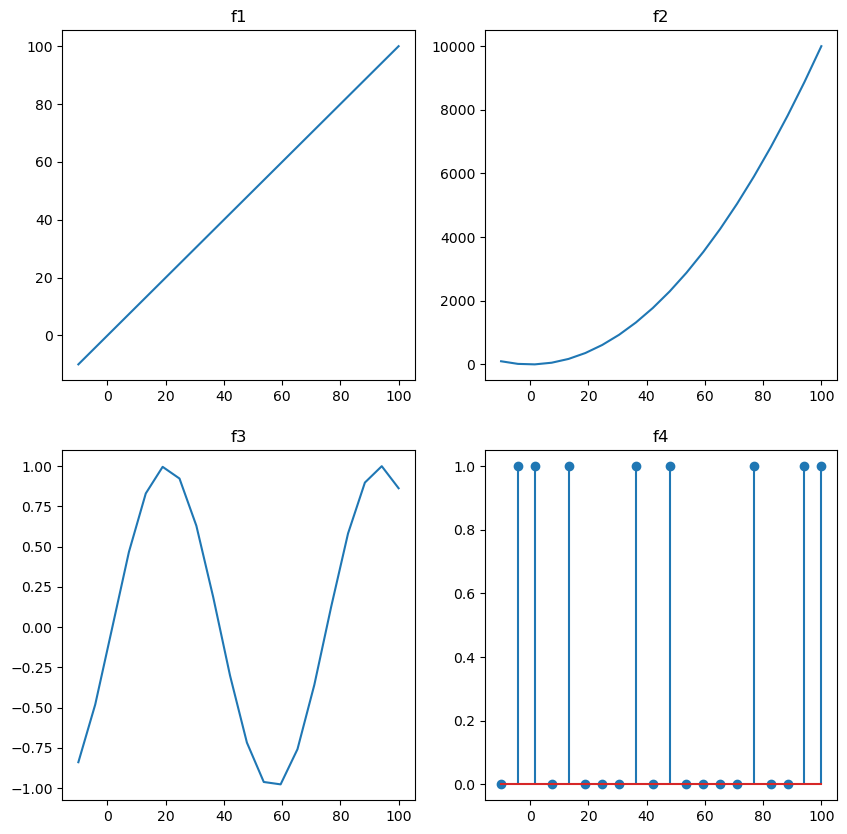

In [26]:
t_min = -10
t_max = 100
N = 20
t = np.linspace(t_min, t_max, N)
print(t)

f1 = t
f2 = t**2
f3 = np.cos(t)
f4 = np.random.randint(0, 2, (N))

#Grafici
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
ax[0, 0].plot(t, f1)
ax[0, 0].set_title('f1')
ax[0, 1].plot(t, f2)
ax[0, 1].set_title('f2')
ax[1, 0].plot(t, f3)
ax[1, 0].set_title('f3')

ax[1, 1].stem(t, f4)
ax[1, 1].set_title('f4')

plt.show()


## 2.2 Podele signala

### 2.2.1 Diskretni vs kontinualni
#### 2.2.1.1 Diskretni signali
$$x[n]$$
#### 2.2.1.2 Kontinualni signal
$$f(t)$$



### 2.2.2 Deterministički vs slučajni

### 2.2.3 Periodični vs aperiodični
$$f(t+T)=f(t),\forall t\in \mathbb{R}$$



### 2.2.4 Parni, neparni i njihov zbir
#### 2.2.4.1 Parni signal
$$f(-t)=f(t)$$
#### 2.2.4.2 Neparni signal
$$f(-t)=-f(t)$$


Svai signal može da se predstavi kao zbir jednog parnog i jednog neparnog signala

## 2.3 Osnovni parametri signala

### 2.3.1 Domen signala
Skup na kome je signal definisan:
$$f(t),t\in \mathbb{R} \lor t\in [a,b]$$
$$x[n],n\in\mathbb{N}\lor n\in \mathbb{Z}$$
### 2.3.2 Srednja vrednost
$$<x[n]>=\frac{1}{N}\sum\limits_{i=0}^{N-1}x_{i}$$
Primer: srednja vrednost funkcije $x$ definisana na $\{0,1,2\}$ je $\frac{x_0+x_1+x_2}{3}$
$$<f(t)>=\frac{1}{b-a}\int_{a}^{b}f(t)dt$$
Delimo integral signala sa dužinom trajanja. Suština se može jasno videti grafički, ako integral posmatramo kao površinu ispod grafika.
### 2.3.3 Energija
$$E(f(t))=\int_{-\infty}^{\infty}f^{2}(t)dt$$
$$E(x[n])=\sum\limits_{n=-\infty}^{\infty}x^2[n]$$
Dobija se sabiranjem kvadrata vrednosti funkcije.
### 2.3.4 Snaga
$$P=\lim_{T\rightarrow{\infty}}\left(\frac{1}{2T}\int_{-T}^{T}f^2(t)dt\right)$$
$$P=\lim_{N\rightarrow{\infty}}\left(\frac{1}{2N}\sum\limits_{-N}^{N}x^2[n]\right)$$
Formalna definicija je zbunjujuća, ali je snaga ekvivalent srednje vrednosti za funcije sa neograničenim domenom.
### 2.3.5 Efektivna vrednost
$$A_{eff}=\sqrt{P}$$


In [27]:
avg_f1 = np.mean(f1)
avg_f1 = np.sum(f1) / len(f1)
energy_f1 = np.sum(f1**2)
power_f1 = energy_f1 / N
effective_value_f1 = np.sqrt(power_f1)

avg_f3 = np.mean(f3)
energy_f3 = np.sum(f3**2)
power_f3 = energy_f3 / N
effective_value_f3 = np.sqrt(power_f3)

print('f1: avg = {}, energy = {}, power = {}, effective value = {}'.format(avg_f1, energy_f1, power_f1, effective_value_f1))
print('f3: avg = {}, energy = {}, power = {}, effective value = {}'.format(avg_f3, energy_f3, power_f3, effective_value_f3))

f1: avg = 45.0, energy = 62789.473684210534, power = 3139.4736842105267, effective value = 56.03100645366391
f3: avg = 0.10478811701329523, energy = 10.20539932007257, power = 0.5102699660036285, effective value = 0.7143318318566159



### 2.3.6 Logaritamske mere
- Amplituda : $A=20\log_{10}\left(\frac{A_{eff}}{A_{0}}\right)$
- Snaga : $P=10\log_{10}\left(\frac{P}{P_{0}}\right)$
- Pojacanje amplitude : $G_A=20\log_{10}\left(\frac{A_{2}}{A_{1}}\right)$
- Pojacanje snage : $G_P=10\log_{10}\left(\frac{P_{2}}{P_{1}}\right)$


## 2.4 Elementarni signali

### 2.4.1 Jedinična odskočna funkcija
$$h[n] = \begin{cases}1,n\geq0\\0,n< 0 \end{cases}$$
$$h(t)=\begin{cases}1,t>0 \\0,t<0\end{cases}$$
$$h(0)=?$$
### 2.4.2 Dirakov impuls
$$\delta[n]=\begin{cases}1,n=0\\0,n\neq0\end{cases}$$
$$\delta(t)=\begin{cases}0 , t\neq0\\ \infty , t=0\end{cases}$$
$$\int_\infty^\infty\delta(t)dt=1$$



Text(0.5, 1.0, 'Dirac')

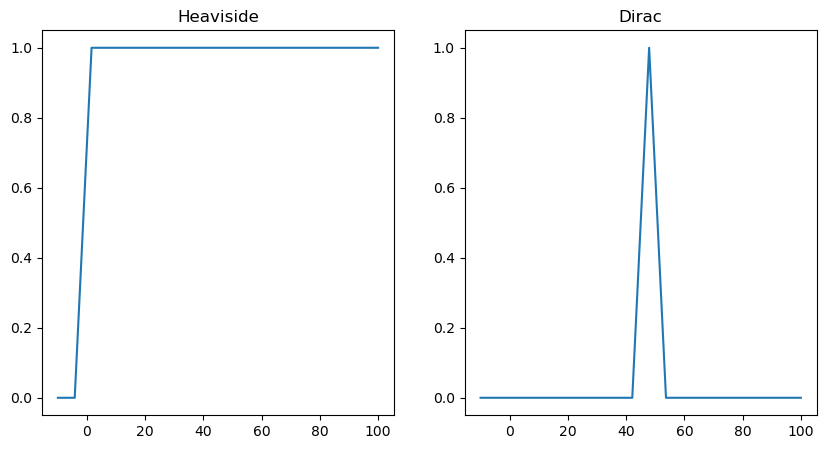

In [28]:
N=20
heaviside=np.heaviside(t,1)
dirac=np.zeros(N)
dirac[N//2]=1
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(t, heaviside)
ax[0].set_title('Heaviside')
ax[1].plot(t, dirac)
ax[1].set_title('Dirac')


## 2.5 Elementarne operacije na signalima

### 2.5.1 Pojačanje
$$G\cdot f(t)$$


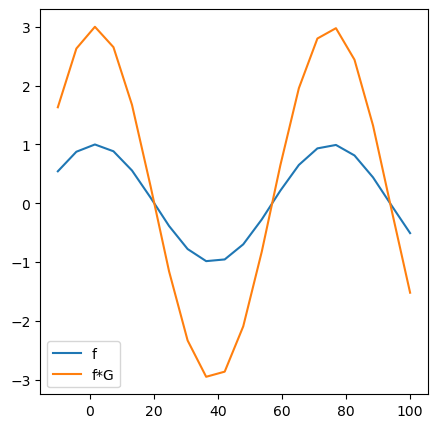

In [29]:
G = 3
f = np.sin(t)
fG = f*G
fig, ax = plt.subplots(1,1, figsize=(5, 5))
ax.plot(t, f, label='f')
ax.plot(t, fG, label='f*G')
ax.legend()


### 2.5.2 Pomeranje u vremenu
$$f(t-t_{0})$$


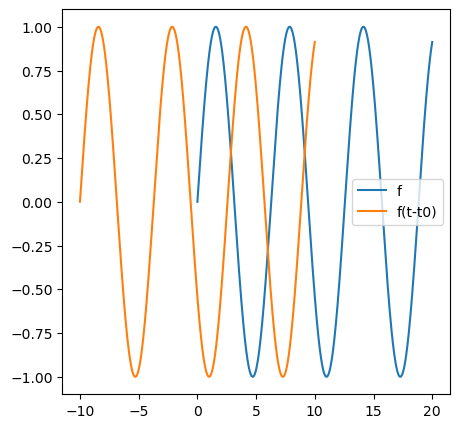

In [54]:
f = np.sin(t)
t0 = 10
fig, ax = plt.subplots(1,1, figsize=(5, 5))
ax.plot(t, f, label='f')
ax.plot(t-t0, f, label='f(t-t0)')
ax.legend()


### 2.5.3 Inverzija vremena
$$f(-t)$$


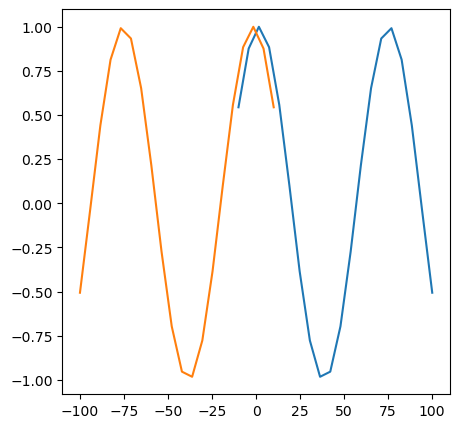

In [31]:
f = np.sin(t)
fi = f[ : :-1]
ti_min = -t_max
ti_max = -t_min
ti = np.linspace(ti_min, ti_max, N)
fig, ax = plt.subplots(1,1, figsize=(5, 5))
ax.plot(t, f, label='f')
ax.plot(ti, fi, label='f(-t)')


### 2.5.4 Skaliranje vremena
$$f(k\cdot t)$$
#### 2.5.4.1 Linearna interpolacija



Originalna funkcija:  [ 1  2  3  4  5  6  7  8  9 10]
Bez interpolacije:  [ 1.  0.  2.  0.  3.  0.  4.  0.  5.  0.  6.  0.  7.  0.  8.  0.  9.  0.
 10.  0.]
[ 1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.   6.5  7.   7.5
  8.   8.5  9.   9.5 10.   0. ]
Konacni rezultat:  [ 1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.   6.5  7.   7.5
  8.   8.5  9.   9.5 10.  10. ]


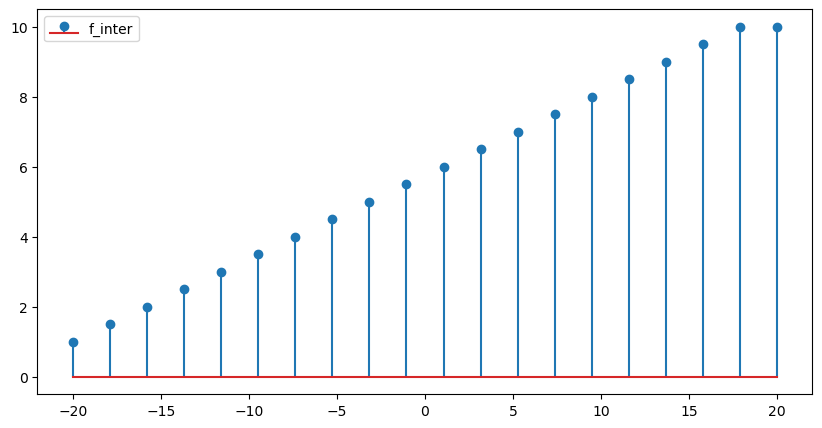

In [32]:
 k = 2
 N = 10
 t = np.linspace(-10, 10, N)
 tc = np.linspace(-10*k, 10*k, 1000)
 t2 = np.linspace(-10*k, 10*k, N*k)
 f = np.sin(t)
 f = np.arange(1,11)


 print("Originalna funkcija: ", f)
 f_inter = np.zeros(len(t)*k)
 f_inter[::k] = f
 print("Bez interpolacije: ", f_inter)
 f_inter[1:-1:k] = (f[1:] + f[:-1])/2#na neparnim mestima popunjava funkciju
 print(f_inter)
 f_inter[-1] =  f_inter[-2]
 print("Konacni rezultat: ",f_inter)
 #Brzi nacin:
 # f_inter[1::k] = (f[1:] + f[:-1])/2
 fig, ax = plt.subplots(1, 1, figsize=(10, 5))
 # ax.stem(t, f, label='f')
 ax.stem(t2, f_inter, label='f_inter')
 # ax.plot(tc, np.sin(tc), label='sin')
 ax.legend()


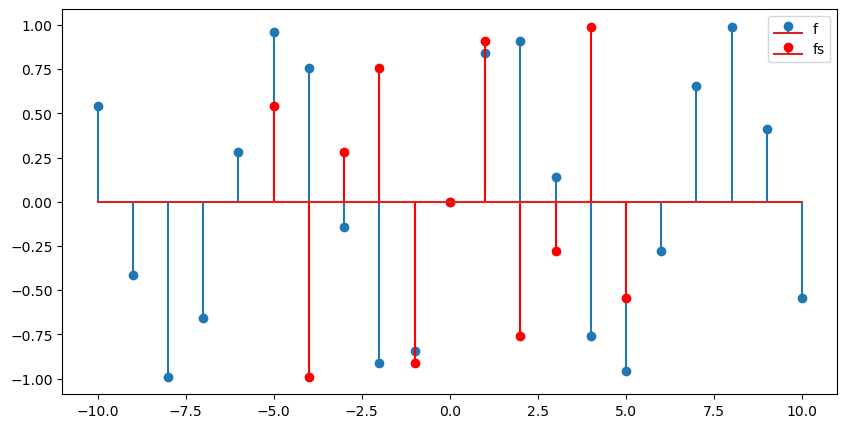

In [33]:
# k = 2
# N = 10
# t = np.linspace(-10, 10, N)
# tc = np.linspace(-10*k, 10*k, 1000)
# t2 = np.linspace(-10*k, 10*k, N*k)
# f = np.sin(t)
# f = np.arange(1,11)
# print("Originalna funkcija: ", f)
# f_inter = np.zeros(len(t)*k)
# f_inter[::k] = f
# print("Bez interpolacije: ", f_inter)
# f_inter[1:-1:k] = (f[1:] + f[:-1])/2
# print(f_inter)
# f_inter[-1] =  f_inter[-2]
# print("Konacni rezultat: ",f_inter)
# #Brzi nacin:
# # f_inter[1::k] = (f[1:] + f[:-1])/2

# fig, ax = plt.subplots(1, 1, figsize=(10, 5))
# # ax.stem(t, f, label='f')
# ax.stem(t2, f_inter, label='f_inter')
# # ax.plot(tc, np.sin(tc), label='sin')
# ax.legend()

k = 2
N = 21
t_min = -10
t_max = 10
t = np.linspace(t_min, t_max, N)
f = np.sin(t)

ts = np.linspace(-10*(1/k), 10*(1/k), N)

#bitno
fs = f[np.equal(np.mod(ts, 1), 0)]
ts = ts[np.equal(np.mod(ts, 1), 0)]

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.stem(t, f, label='f')
ax.stem(ts, fs, label='fs', linefmt='r')
ax.legend()

## 2.6 Ne bas elementarni signali


### 2.6.1 Pravougaoni impuls


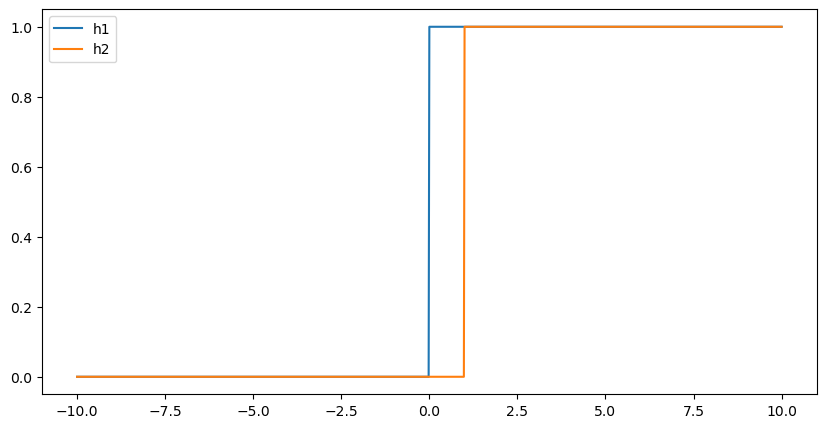

In [34]:
t = np.linspace(-10, 10, 1001)
h1 = np.heaviside(t, 1)
h2 = np.heaviside(t-1, 1)
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(t, h1, label='h1')
ax.plot(t, h2, label='h2')
ax.legend()

/tmp/ipykernel_21518/279632932.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


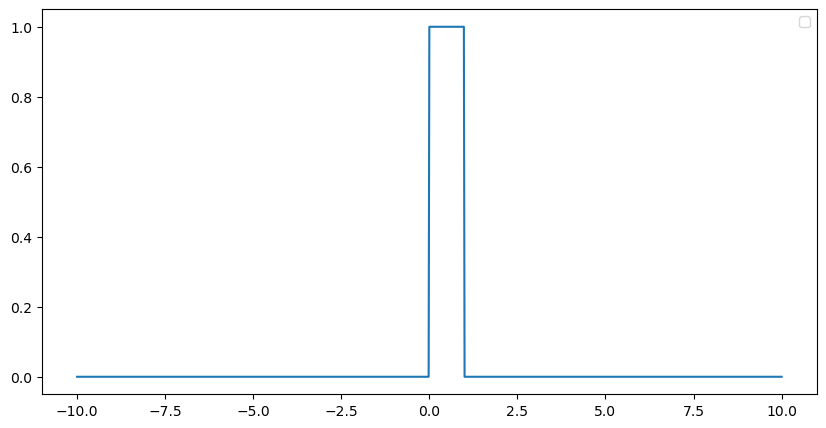

In [35]:
r = h1 - h2
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(t, r)
ax.legend()

$$u(t)-u(t-t_{0})$$



### 2.6.2 Sinus i kosinus
$$\begin{aligned}
\sin(2\pi f_{0t}+\varphi)&=\sin(\omega_{0}t+\varphi)\\
\cos(2\pi f_{0t}+\varphi)&=\cos(\omega_{0}t+\varphi)\\
e^{j2\pi f_{0}t}=e^{j\omega_{0}t}&=\cos(\omega_{0}t)+j*\sin(\omega_{0}t)
\end{aligned}
$$
$$j = i = \sqrt{-1}$$

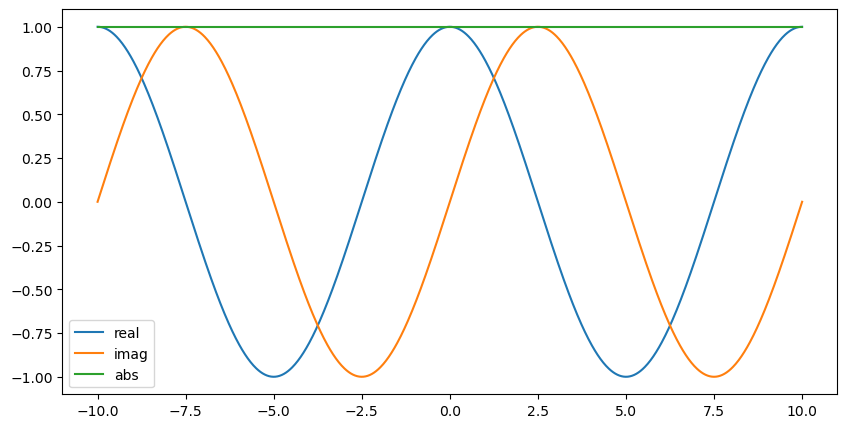

interactive(children=(FloatSlider(value=0.1, description='f0', max=1.0, min=0.1), Output()), _dom_classes=('wi…

<function __main__.plot_sine_cosine(f0)>

In [36]:

def plot_sine_cosine(f0):
    

    #bitno:
    eix = np.exp(1j*2*np.pi*f0*t1)
    
    #grafik:
    lines1[0][0].set_data(t1, eix.real)
    lines1[1][0].set_data(t1, eix.imag)
    lines1[2][0].set_data(t1, np.abs(eix))
    fig1.canvas.draw_idle()

#bitno:
f0_1 = 0.1
t1 = np.linspace(-10, 10, 1000)
eix1 = np.exp(1j*2*np.pi*f0_1*t1)

#grafik:
fig1, ax1 = plt.subplots(1, 1, figsize=(10, 5))
lines1 = []
lines1.append(ax1.plot(t1, eix1.real, label='real'))
lines1.append(ax1.plot(t1, eix1.imag, label='imag'))
lines1.append(ax1.plot(t1, np.abs(eix1), label='abs'))
ax1.legend()

interact(plot_sine_cosine, f0=FloatSlider(min=0.1, max=1, step=0.1, value=0.1))

## Eksponencijalni signal
$$e^{at}$$
$$a\in \mathbb{C}$$
$$a=\sigma+j\omega$$
$$e^{at}=e^{\sigma t}e^{j\omega t}$$

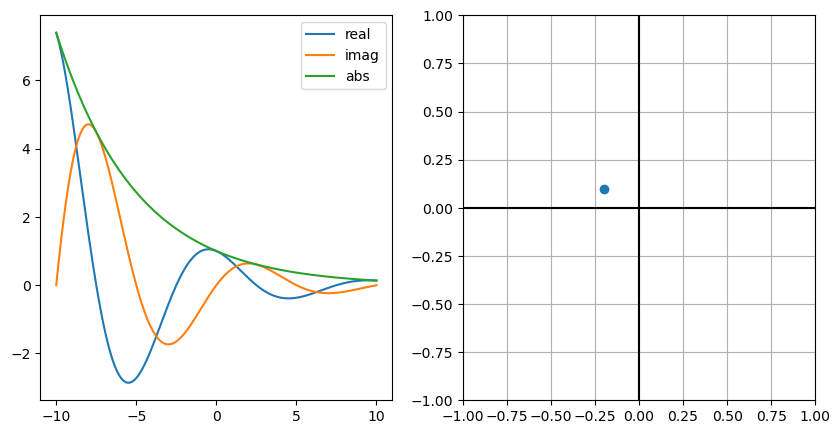

interactive(children=(FloatSlider(value=0.1, description='f0', max=1.0, min=-1.0), FloatSlider(value=0.0, desc…

<function __main__.plot_exp(f0, sigma)>

In [37]:
N = 1000
t_min = -10
t_max = 10
t = np.linspace(t_min, t_max, N)
f0 = 0.1
sigma = -0.2
sin = np.sin(2*np.pi*f0*t)
cos = np.cos(2*np.pi*f0*t)

def plot_exp(f0, sigma):
    N = 1000
    t_min = -10
    t_max = 10
    t = np.linspace(t_min, t_max, N)
    #bitno:
    eix = np.exp(1j*2*np.pi*f0*t) * np.exp(sigma*t)

    #crtanje:
    lines2[0][0].set_data(t, eix.real)
    lines2[1][0].set_data(t, eix.imag)
    lines2[2][0].set_data(t, np.abs(eix))
    scatter2.set_offsets(np.array([sigma, f0]).reshape(1, -1))
    fig2.canvas.draw_idle()

#bitno:
eix2 = np.exp(1j*2*np.pi*f0*t) * np.exp(sigma*t)

#crtanje:
fig2, ax2 = plt.subplots(1, 2, figsize=(10, 5))
lines2 = []
lines2.append(ax2[0].plot(t, eix2.real, label='real'))
lines2.append(ax2[0].plot(t, eix2.imag, label='imag'))
lines2.append(ax2[0].plot(t, np.abs(eix2), label='abs'))
ax2[0].legend()
scatter2 = ax2[1].scatter(sigma, f0)
ax2[1].set_xlim(-1, 1)
ax2[1].set_ylim(-1, 1)
ax2[1].axhline(y=0, color='k')
ax2[1].axvline(x=0, color='k')
ax2[1].grid()

interact(plot_exp, f0=FloatSlider(min=-1, max=1, step=0.1, value=0.1), sigma=FloatSlider(min=-0.5, max=0.5, step=0.05, value=0))

# 4 Uvod u sisteme



## 4.1 Primeri sistema



Za razmišljanje:
- Kako sve možemo da podelimo sisteme?
- Koje osobine sistemi mogu da imaju?

Primeri sistema:
- Mikrofon
- Zvučnik
- Otpornik
- Kondenzator

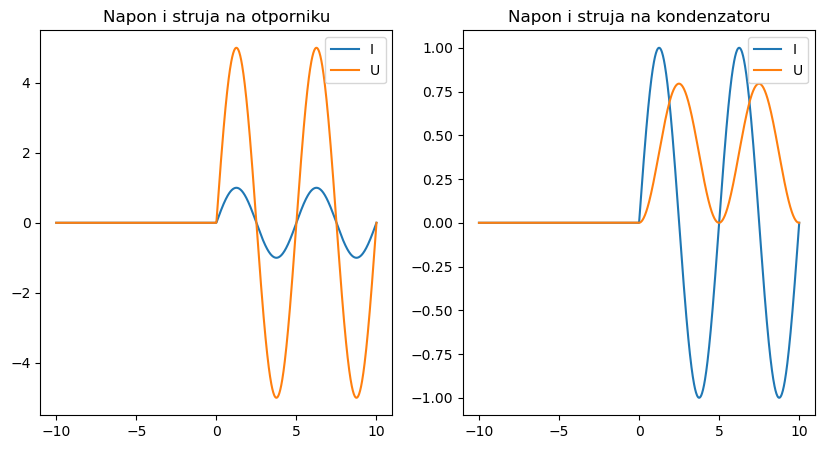

In [38]:
t_min = -10
t_max = 10
N = 1000
R, C = 5, 100
t = np.linspace(t_min, t_max, N)
f0 = 0.2
I = np.sin(2*np.pi*f0*t)
I[:N//2] = 0
 
U_R = I*R

U_C = 1/C * np.cumsum(I)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(t, I, label='I')
ax[0].plot(t, U_R, label='U')
ax[0].legend()
ax[0].set_title('Napon i struja na otporniku')
ax[1].plot(t, I, label='I')
ax[1].plot(t, U_C, label='U')
ax[1].set_title('Napon i struja na kondenzatoru')
ax[1].legend()



## 4.3 Osobine sistema



### Sistemi sa memorijom

### Kauzalni sistemi

### Linearni sistemi
- aditivnost
    $$ y(x_1(t)+x_2(t))=y(x_1(t))+y(x_2(t))$$
- homogenost
    $$y(\alpha x(t))=\alpha y(x(t))$$

### Stacionarni (vremenski nepromenljivi) sistemi
$$y(x(t-t_0))=y(x(t))$$

# 5 Konvolucija

## Motivacija
$$x[n] = \sum\limits_{k=-\infty}^{+\infty}x[k]\delta[n-k]$$


## Konvolucija u diskretnom domenu
$$
\begin{aligned}
y[n] = \sum\limits_{k=-\infty}^{+\infty}x[k]h[n-k] \\
y[n] = x[n]\ast h[n]
\end{aligned}
$$


## Konvolucija u kontinualnom domenu
$$\begin{aligned}
y(t) &= \int_{-\infty}^{+\infty}x(\tau)h(t-\tau)d\tau \\
y(t) &= x(t)\ast h(t)
\end{aligned}$$


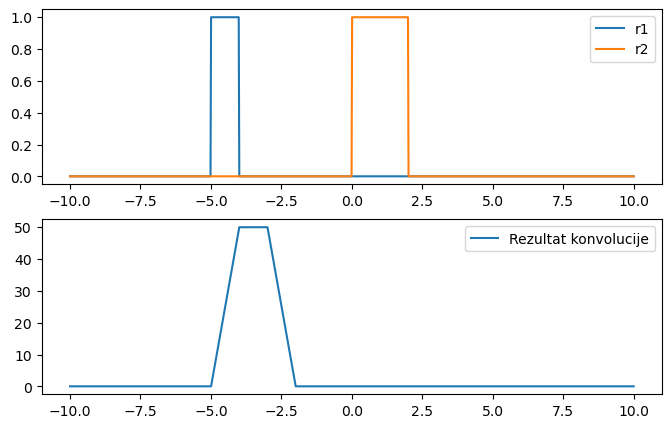

In [39]:
t = np.linspace(-10, 10, 1000)
r1 = np.heaviside(t+5, 1) - np.heaviside(t+4, 1)
r2 = np.heaviside(t, 1) - np.heaviside(t-2, 1)

r3 = np.convolve(r1, r2, 'same')
fig, ax = plt.subplots(2, 1, figsize=(8, 5))
ax[0].plot(t, r1, label='r1')
ax[0].plot(t, r2, label='r2')

ax[0].legend()
ax[1].plot(t, r3, label='Rezultat konvolucije')
ax[1].legend()

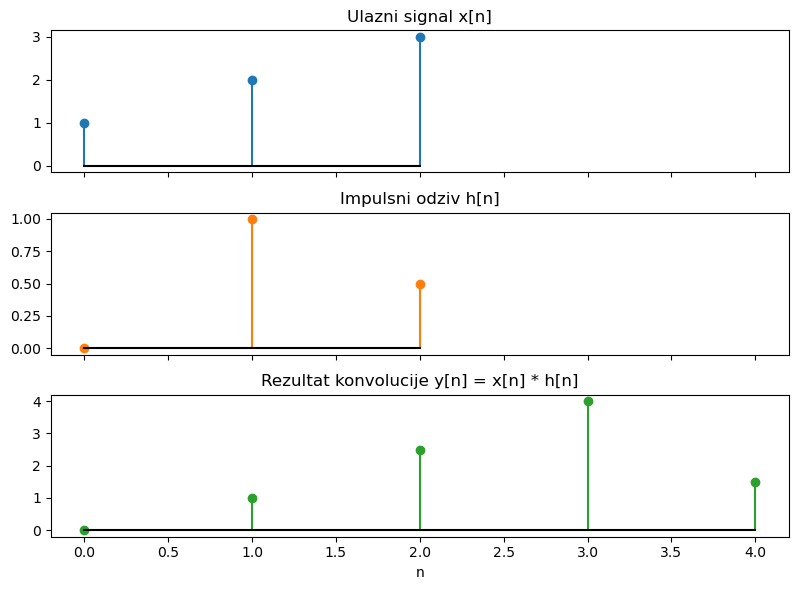

In [40]:
x = np.array([1, 2, 3])
h = np.array([0, 1, 0.5])
y = np.convolve(x, h)

n_x = np.arange(len(x))
n_h = np.arange(len(h))
n_y = np.arange(len(y))

fig, ax = plt.subplots(3, 1, figsize=(8, 6), sharex=True)

ax[0].stem(n_x, x, basefmt='k-', linefmt='C0-', markerfmt='C0o')
ax[0].set_title('Ulazni signal x[n]')

ax[1].stem(n_h, h, basefmt='k-', linefmt='C1-', markerfmt='C1o')
ax[1].set_title('Impulsni odziv h[n]')

ax[2].stem(n_y, y, basefmt='k-', linefmt='C2-', markerfmt='C2o')
ax[2].set_title('Rezultat konvolucije y[n] = x[n] * h[n]')
ax[2].set_xlabel('n')

plt.tight_layout()
plt.show()

# 6 LTI sistem

## 6.1 Impulsni odziv sistema
$$h(t)=y(\delta(t))$$
$$h[n]=y(\delta[n])$$

## Veza impulsnog odziva i konvolucije

# 7 Furijeova transformacija


## 7.1 Furijeov red
$$c_n = \frac{1}{T} \int_{-\frac{T}{2}}^{\frac{T}{2}} f(t) e^{-j2\pi f_0 n t} dt$$

$$ f(t) = \sum\limits_{n=-\infty}^{+\infty} c_n e^{j2\pi f_0 n t}$$

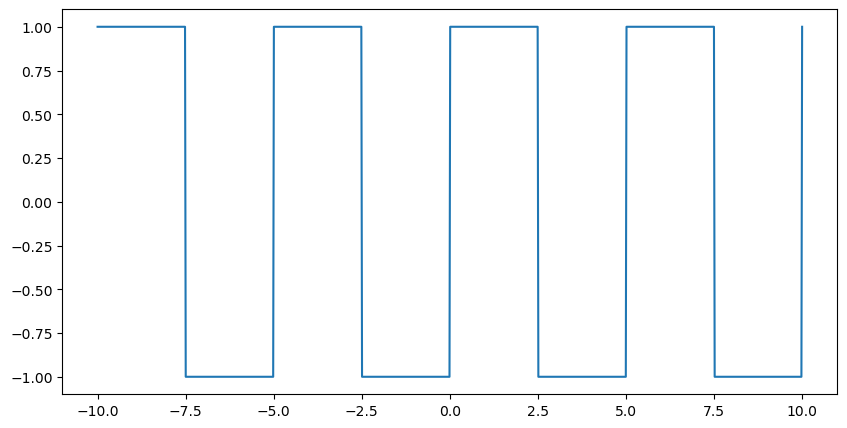

In [41]:
t = np.linspace(-10, 10, 1000)
f0 = 0.2
rect_periodic = scipy.signal.square(2*np.pi*f0*t)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(t, rect_periodic, label='rect_periodic')


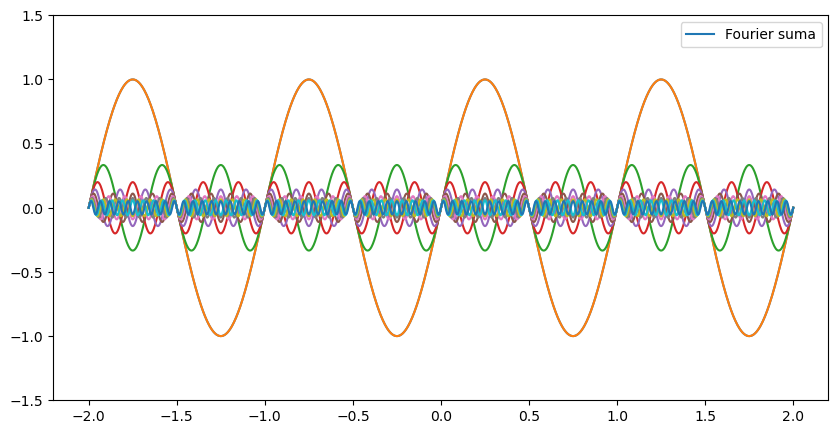

interactive(children=(IntSlider(value=1, description='n', max=10, min=1), Output()), _dom_classes=('widget-int…

<function __main__.plot_fourier(n)>

In [ ]:

f0 = 1
t = np.linspace(-2, 2, 1000)

sines = []
for i in range(0, 100):
    s = np.sin(2*np.pi*(2*i+1)*f0*t)/(2*i+1)
    sines.append(s)
sines = np.array(sines)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
line_sum, = ax.plot(t, np.sum(sines[:1], axis=0), label='Fourier suma')
lines = [ax.plot(t, sines[i])[0] for i in range(10)]  

ax.set_ylim(-1.5, 1.5)
ax.legend()

def plot_fourier(n):
    rect = np.sum(sines[:n], axis=0)
    line_sum.set_data(t, rect)

    for i, l in enumerate(lines):
        if i < n:
            l.set_data(t, sines[i])
        else:
            l.set_data([], [])

    fig.canvas.draw_idle()

interact(plot_fourier, n=IntSlider(min=1, max=10, step=1, value=1))


## 7.2 Furijeova transformacija
$$F(f) = \int_{-\infty}^{+\infty} f(t) e^{-j2\pi f t} dt$$
$$f(t) = \int_{-\infty}^{+\infty} F(f) e^{j2\pi f t} df$$

(0.0, 5.0)

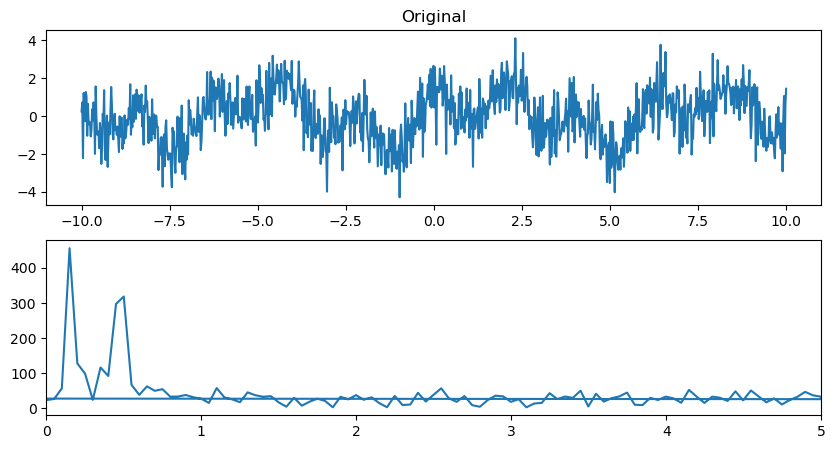

In [43]:
t = np.linspace(-10,10,1000)
f1s=np.sin(t)
f2s=np.sin(3*t +np.pi/2)
noise=np.random.randn(1000)
sig=f1s+f2s+noise

fig, ax = plt.subplots(2, 1, figsize=(10, 5))
ax[0].plot(t,sig)
ax[0].set_title("Original")

f1=fft.fft(sig)
freq=fft.fftfreq(len(sig),t[1]-t[0])

ax[1].plot(freq,np.abs(f1))
ax[1].set_xlim(0,5)


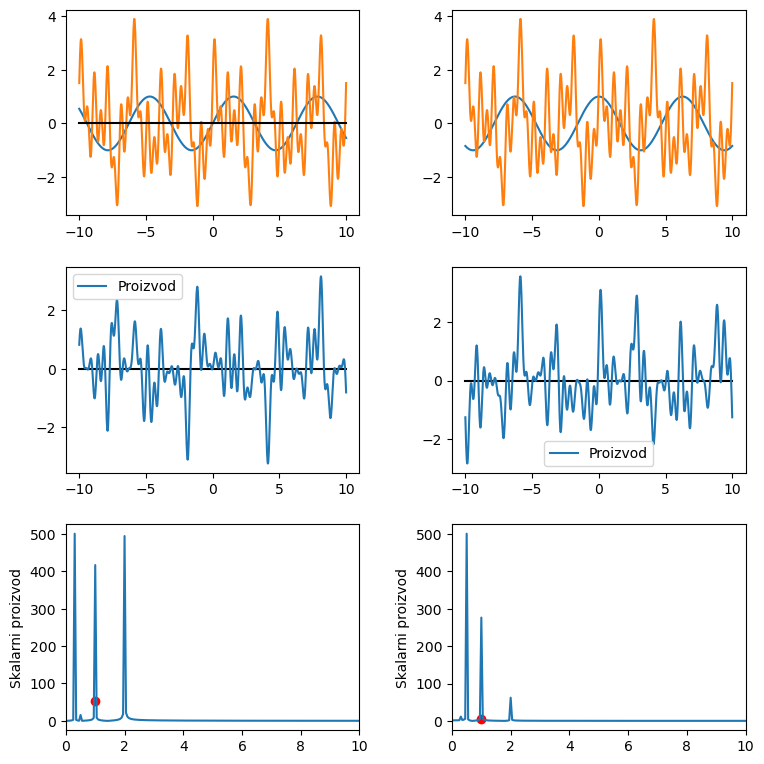

interactive(children=(FloatSlider(value=1.0, description='w', max=10.0, min=0.1), Output()), _dom_classes=('wi…

<function __main__.plot_fourier_transform(w=1.0)>

In [44]:
t = np.linspace(-10, 10, 1000)

f1s = np.sin(t)
f1c = np.cos(t)
signal2 = np.sin(2*np.pi*2*t) + np.cos(2*np.pi*0.5*t) + np.sin(2*np.pi*0.3*t) + np.sin(2*np.pi*t + np.pi/6) #nas signal
ft    = np.fft.fft(signal2) #rezultat
freq = np.fft.fftfreq(len(signal2), t[1]-t[0]) 


#crtanje
fig5 = plt.figure(figsize =(8,8))
ax11 = fig5.add_subplot(3, 2, 1)
line1s_5, = ax11.plot(t, f1s)
ax12 = fig5.add_subplot(3, 2, 2)
line1c_5, = ax12.plot(t, f1c)
line21, = ax11.plot(t, signal2)
line22, = ax12.plot(t, signal2)
ax11.add_line(Line2D([-10,10], [0,0],color='black'))
ax21 = fig5.add_subplot(3, 2, 3)
ax21.add_line(Line2D([-10,10], [0,0],color='black'))
ax22 = fig5.add_subplot(3, 2, 4)
ax22.add_line(Line2D([-10,10], [0,0],color='black'))
line3s_5, = ax21.plot(t, f1s*signal2,label="Proizvod")
line3c_5, = ax22.plot(t, f1c*signal2,label="Proizvod")
ax21.legend()
ax22.legend()
ax31 = fig5.add_subplot(3, 2, 5)
ax32 = fig5.add_subplot(3, 2, 6)
scatters_5 = ax31.scatter([1], [np.sum(f1s*signal2)], c=['r'])
scatterc_5 = ax32.scatter([1], [np.sum(f1c*signal2)], c=['r'])
line4s, = ax31.plot(freq[:np.shape(ft)[0]//2], np.abs(np.imag(ft[:np.shape(ft)[0]//2])))
line4c, = ax32.plot(freq[:np.shape(ft)[0]//2], np.abs(np.real(ft[:np.shape(ft)[0]//2])))
ax31.set_xlim(0, 10)
ax32.set_xlim(0, 10)
ax31.set_ylabel('Skalarni proizvod')
ax32.set_ylabel('Skalarni proizvod')
fig5.tight_layout(pad=2)


def plot_fourier_transform(w = 1.0):
    t = np.linspace(-10, 10, 1000)
    f1s = np.sin(2*np.pi*w * t)
    f1c = np.cos(2*np.pi*w * t)

    #crtanje:
    line1s_5.set_ydata(f1s)
    line1c_5.set_ydata(f1c)
    line3s_5.set_ydata(f1s*signal2)
    line3c_5.set_ydata(f1c*signal2)
    scatters_5.set_offsets(np.c_[[w], [np.abs(np.sum(f1s*signal2))]])
    scatterc_5.set_offsets(np.c_[[w], [np.abs(np.sum(f1c*signal2))]])
    fig5.canvas.draw_idle()

interact(plot_fourier_transform, w=(0.1, 10.0, 0.1))

/usr/lib64/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/lib64/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0.5, 1.0, 'Zbir FFT shift-ovanih signala')

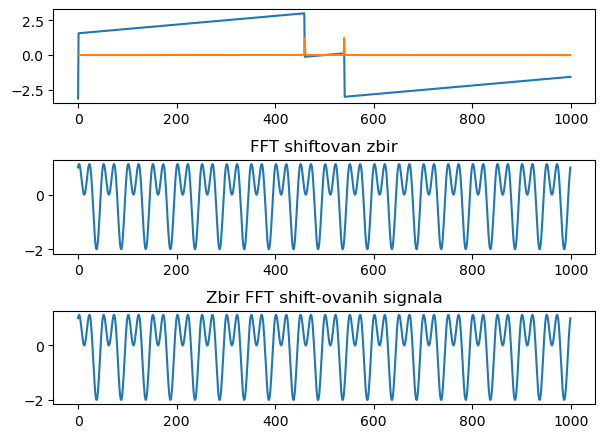

In [45]:
t = np.linspace(-10, 10, 1000)

f1 = np.sin(2*np.pi*1*t)
f2 = np.cos(2*np.pi*2*t)
f12 = f1 + f2

ft_f1 = np.fft.fftshift(np.fft.fft(f1))
ft_f2 = np.fft.fftshift(np.fft.fft(f2))

ft_f12 = np.fft.fftshift(np.fft.fft(f12))

f12r = np.fft.ifft(np.fft.ifftshift(ft_f1) + np.fft.ifftshift(ft_f2))

fig, ax = plt.subplots(3,1)
fig.tight_layout(pad=2)
# ax[0].plot(np.angle(ft_f1), label="sin")
ax[0].plot(np.angle(ft_f2), label="ugao")
# ax[0].plot(np.abs(ft_f1)/400, label="sin")
ax[0].plot(np.abs(ft_f2)/400, label="modul")

ax[1].plot(f12)
ax[1].set_title("FFT shiftovan zbir")
ax[2].plot(f12r)
ax[2].set_title("Zbir FFT shift-ovanih signala")




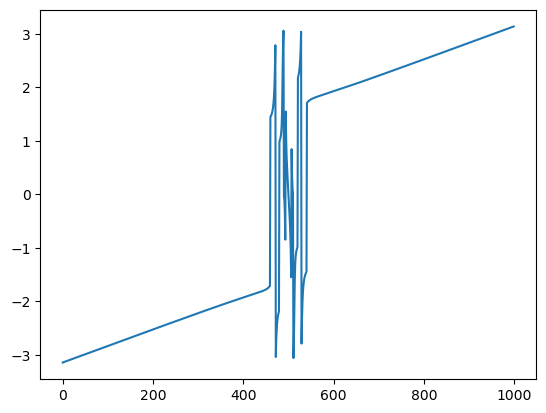

In [46]:
t = np.linspace(-10, 10, 1000)
f2 = np.sin(2*np.pi*2*t) + np.cos(2*np.pi*0.5*t) + np.sin(2*np.pi*0.3*t) + np.sin(2*np.pi*t + np.pi/6)

spec = np.fft.fft(f2)

fig, ax = plt.subplots(1,1)
ax.plot(np.angle(np.fft.fftshift(spec)))


## 7.3 Veza furijeove transformacije i impulsnog odziva


# 8 Spektar signala
- Linearnost
- Pomeranje u vremenu
- Modulacija
- Vremensko skaliranje
- Simetrija

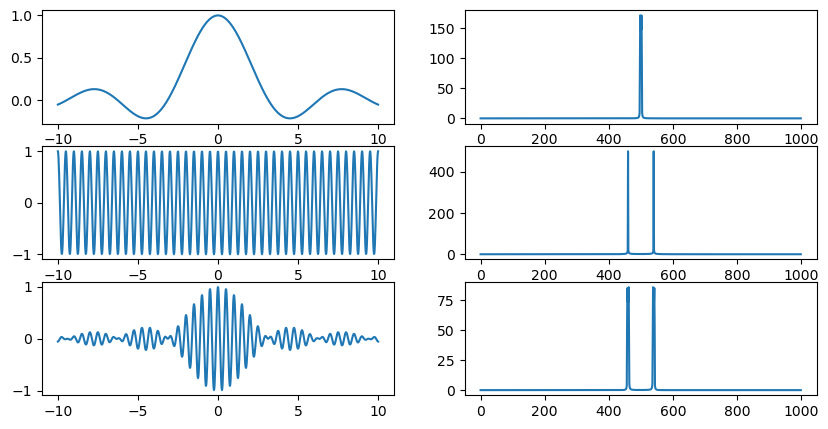

interactive(children=(FloatSlider(value=5.0, description='f0', max=10.0, min=0.1), Output()), _dom_classes=('w…

<function __main__.plot_fftshift(f0)>

In [47]:
t = np.linspace(-10, 10, 1000)
f1 = np.sin(t)/t
f0 = 2

mf1 = np.cos(2*np.pi*f0*t)*f1

def plot_fftshift(f0):
    t = np.linspace(-10, 10, 1000)
    f1 = np.sin(t)/t
    mf1 = np.cos(2*np.pi*f0*t)*f1
    line1_6[0].set_ydata(mf1)
    line2_6[0].set_ydata(np.abs(np.fft.fftshift(np.fft.fft(mf1))))
    line1c_6[0].set_ydata(np.cos(2*np.pi*f0*t))
    line2c_6[0].set_ydata(np.abs(np.fft.fftshift(np.fft.fft(np.cos(2*np.pi*f0*t)))))

fig, ax = plt.subplots(3, 2, figsize=(10, 5))
ax[0][0].plot(t, f1)
ax[0][1].plot(np.abs(np.fft.fftshift(np.fft.fft(f1))))
line1c_6 = ax[1][0].plot(t, np.cos(2*np.pi*f0*t))
line2c_6 = ax[1][1].plot(np.abs(np.fft.fftshift(np.fft.fft(np.cos(2*np.pi*f0*t)))))
line1_6 = ax[2][0].plot(t, mf1)
line2_6 = ax[2][1].plot(np.abs(np.fft.fftshift(np.fft.fft(mf1))))
interact(plot_fftshift, f0=(0.1, 10.0, 0.1))


# 9 Diskretizacija vremena


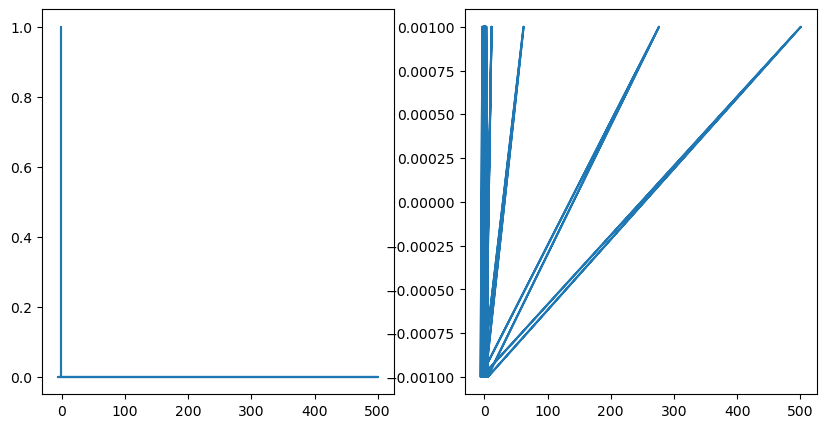

interactive(children=(IntSlider(value=10, description='n', max=20), Output()), _dom_classes=('widget-interact'…

<function __main__.plot_triangles(n)>

In [48]:
def triangle(x):
    def f(x):
        return -(np.abs(x) - 1)

    return f(x) * (np.sign(f(x)) + 1) / 2

specter = triangle(ft*16)
for i in range(-20, 20):
    if i == 0: continue
    specter += triangle(ft*16 - i*8)
specter = np.fft.fftshift(specter)
specter = specter.astype(np.complex128)
inverse = np.fft.ifft(specter)
inverse = np.fft.ifftshift(inverse)


def plot_triangles(n):
    #Bitno:
    ft = np.linspace(-10, 10, 1000)
    specter = triangle(ft*16)
    for i in range(-n, n):
        if i == 0: continue
        specter += triangle(ft*16 - i*8)
    specter = np.fft.fftshift(specter)
    specter = specter.astype(np.complex128)
    inverse = np.fft.ifft(specter)
    inverse = np.fft.ifftshift(inverse)
    specter = np.fft.ifftshift(specter)

    #Crtanje:
    line1_7[0].set_ydata((specter+1))
    ax7[1].clear()
    line2 = ax7[1].plot(ft, inverse)

fig, ax7 = plt.subplots(1, 2, figsize=(10, 5))
line1_7 = ax7[0].plot(ft, specter)
line2 = ax7[1].plot(ft, inverse)

interact(plot_triangles, n=(0, 20, 1))

/tmp/ipykernel_21518/3380118575.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_21518/3380118575.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_21518/3380118575.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_21518/3380118575.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_21518/3380118575.py:32: UserWarning: No artists with labels found to put in legend.  Note tha

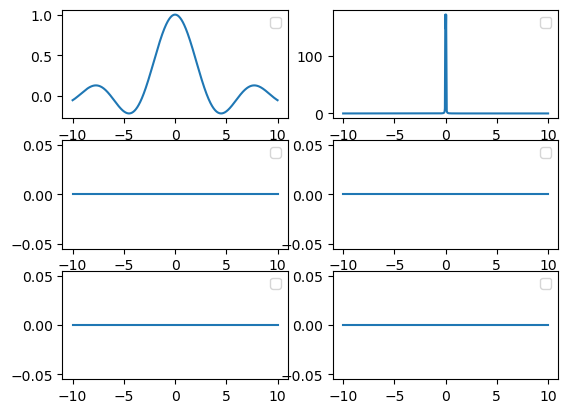

interactive(children=(IntSlider(value=50, description='T', min=1), Output()), _dom_classes=('widget-interact',…

<function __main__.plot_dirac(T)>

In [49]:
def f(x):
    return np.sin(x)/x

def dirac_per(x, T):
    x = np.zeros_like(x)
    x[::T] = 1
    return x

ft = np.linspace(-10, 10, 1000)
y = f(ft)
dirac = np.zeros_like(ft)
def plot_dirac(T):
    ft = np.linspace(-10, 10, 1000)
    dirac = dirac_per(ft, T)
    line1_8.set_ydata(dirac)
    line2_8.set_ydata(y*dirac)
    line3_8.set_ydata(np.abs(np.fft.fft(dirac)))
    line4_8.set_ydata(np.log(np.abs(np.fft.fft(y*dirac))+1))

fig = plt.figure()
ax = fig.add_subplot(3, 2, 1)
ax.legend()
line, = ax.plot(ft, y)

ax.legend()
ax = fig.add_subplot(3, 2, 3)
ax.legend()
line1_8, = ax.plot(ft, dirac)
ax.legend()
ax = fig.add_subplot(3, 2, 5)
line2_8, = ax.plot(ft, y*dirac)
ax.legend()

ax = fig.add_subplot(3, 2, 2)
line, = ax.plot(ft, np.abs(np.fft.fftshift(np.fft.fft(y))))
ax.legend()
ax = fig.add_subplot(3, 2, 4)
line3_8, = ax.plot(ft, np.abs(np.fft.fftshift(np.fft.fft(dirac))))
ax.legend()
ax = fig.add_subplot(3, 2, 6)
line4_8, = ax.plot(ft, np.log(np.abs(np.fft.fftshift(np.fft.fft(y*dirac)))+1))
ax.legend()
interact(plot_dirac, T=(1, 100, 1))




# 10 STFT - Short time Fourier transform 



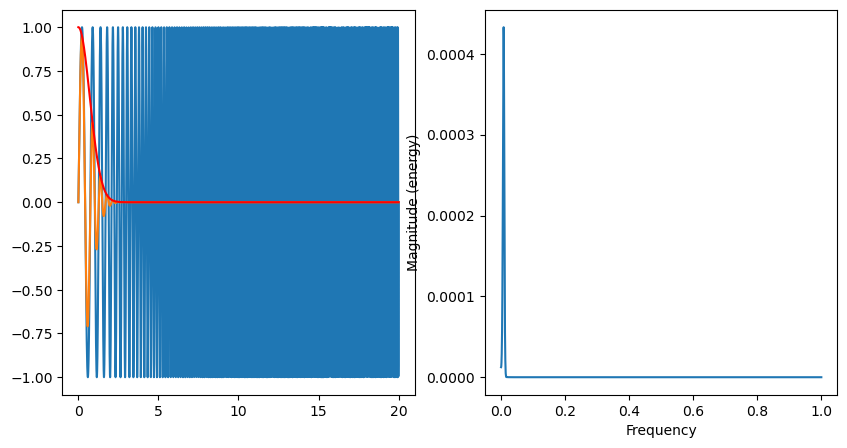

interactive(children=(FloatSlider(value=0.0, description='t0', max=10.0, min=-10.0), Output()), _dom_classes=(…

<function __main__.plot_stft(t0)>

In [50]:
t = np.linspace(0, 20, 10000)
f0 = np.linspace(1, 10, 10000)
# f0 = np.log(f0t)
t1 = np.linspace(-10, 10, 10000)
f = np.sin(2*np.pi * f0 * t)
t0 = -10
window = np.exp(-(t1-t0)**2)
product = f*window

lines_9 = []
fig9, ax9 = plt.subplots(1, 2, figsize=(10, 5))
ax9[0].plot(t, f)
lines_9.append(ax9[0].plot(t, product))
lines_9.append(ax9[0].plot(t, window, c='r'))
test = ax9[1].magnitude_spectrum(f*window)

def plot_stft(t0):
    
    window = np.exp(-(t1-t0)**2)
    product = f*window


    lines_9[0][0].set_ydata(product)
    lines_9[1][0].set_ydata(window)
    ax9[1].clear()
    test = ax9[1].magnitude_spectrum(product)
    ax9[1].set_xlim(0, 0.2)

    fig9.canvas.draw_idle()

interact(plot_stft, t0=(-10, 10, 0.1))

(array([[4.78538282e+01, 2.15464156e+01, 1.28215246e+00, ...,
         5.62735534e-06, 8.26442981e-06, 4.62511472e-06],
        [4.43874349e+01, 3.85712557e+01, 3.87629134e+01, ...,
         1.39686706e-05, 1.97923745e-05, 1.19114793e-05],
        [2.24159192e+00, 4.41177296e+00, 7.19204149e+00, ...,
         2.47846895e-05, 3.25948459e-05, 2.23684126e-05],
        ...,
        [4.50539755e-15, 1.30745974e-14, 8.96131492e-15, ...,
         1.06560653e-13, 1.35733471e-14, 1.82921771e-14],
        [1.12517236e-15, 4.12405691e-15, 6.03634281e-15, ...,
         9.84672797e-14, 1.13267793e-14, 1.89190782e-14],
        [9.58720447e-20, 5.72107856e-16, 2.53150692e-15, ...,
         4.78881833e-14, 5.29081951e-15, 9.56532435e-15]], shape=(129, 77)),
 array([0.       , 0.0078125, 0.015625 , 0.0234375, 0.03125  , 0.0390625,
        0.046875 , 0.0546875, 0.0625   , 0.0703125, 0.078125 , 0.0859375,
        0.09375  , 0.1015625, 0.109375 , 0.1171875, 0.125    , 0.1328125,
        0.140625 , 0.14843

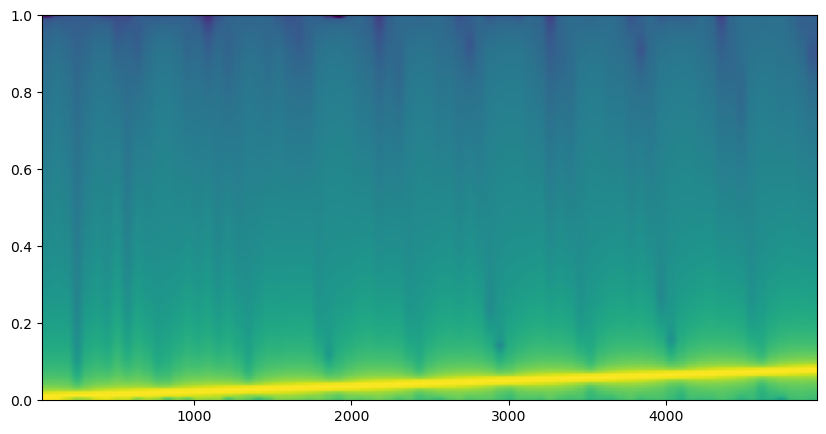

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.specgram(f)